# Traffic Sign Classification — CNN
**Course:** Deep Learning  
**Model:** Convolutional Neural Network (CNN)  
**Dataset:** GTSRB — German Traffic Sign Recognition Benchmark  
**Classes:** 43 traffic sign types  
**Experiments:** Adam optimizer vs SGD optimizer

---
## Requirements Checklist
- [x] Real-world dataset (GTSRB)
- [x] Preprocessing: normalization, resizing, encoding
- [x] CNN with multiple hidden layers
- [x] Enhancements: Dropout + Data Augmentation
- [x] Training with loss & accuracy monitoring
- [x] Evaluation on test set
- [x] 2 experiments (Adam vs SGD)
- [x] Training vs Validation loss & accuracy curves
- [x] Comparison table

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/traffic_sign_project/results'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Results will be saved to: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Results will be saved to: /content/drive/MyDrive/traffic_sign_project/results


## Cell 2 — Install Kaggle & Download GTSRB Dataset

In [2]:
import os

# Paste your token value here (the string starting with KGAT_...)
KAGGLE_TOKEN = "#"  # ← your actual token
KAGGLE_USERNAME = "#"                  # ← your Kaggle username

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_json = f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_TOKEN}"}}'

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(kaggle_json)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [3]:
# Download GTSRB dataset (~300MB) — run only once
print('Downloading GTSRB dataset...')
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip -q gtsrb-german-traffic-sign.zip -d gtsrb
print('Done!')
!ls gtsrb/

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
gtsrb-german-traffic-sign.zip: Skipping, found more recently modified local copy (use --force to force download)
replace gtsrb/Meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Done!
meta  Meta  Meta.csv  test  Test  Test.csv  train  Train  Train.csv


## Cell 3 — Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

# Constants
IMG_SIZE   =  80
NUM_CLASSES = 43     # GTSRB has 43 sign classes
EPOCHS     =  15
BATCH_SIZE =  32
RANDOM_SEED = 42

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 4 — Load & Preprocess Data

In [5]:
def load_gtsrb_data(data_dir, img_size=64):
    """
    Loads GTSRB images from class subfolders.
    Each subfolder is named 0 to 42 (the class label).
    Returns X (images) and y (labels) as numpy arrays.
    """
    images = []
    labels = []

    for class_id in range(NUM_CLASSES):
        class_folder = os.path.join(data_dir, str(class_id))
        if not os.path.exists(class_folder):
            continue
        for img_file in os.listdir(class_folder):
            if img_file.endswith(('.png', '.jpg', '.ppm')):
                img_path = os.path.join(class_folder, img_file)
                img = Image.open(img_path).convert('RGB')
                img = img.resize((img_size, img_size))
                images.append(np.array(img))
                labels.append(class_id)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y


# ------ Locate the train folder ------
TRAIN_DIR = 'gtsrb/Train'
print(f'Loading training data from: {TRAIN_DIR}')
print('This may take 2-3 minutes...')

X, y = load_gtsrb_data(TRAIN_DIR, img_size=IMG_SIZE)

print(f'\nLoaded {len(X)} images')
print(f'Image shape : {X[0].shape}')
print(f'Pixel range : {X.min():.0f} to {X.max():.0f}')
print(f'Label range : {y.min()} to {y.max()}')

Loading training data from: gtsrb/Train
This may take 2-3 minutes...

Loaded 39209 images
Image shape : (80, 80, 3)
Pixel range : 0 to 255
Label range : 0 to 42


In [6]:
# ---- PREPROCESSING ----

# 1. Normalize pixel values from [0, 255] to [0.0, 1.0]
X = X / 255.0
print(f'After normalization — pixel range: {X.min():.2f} to {X.max():.2f}')

# 2. One-hot encode labels: 5 -> [0,0,0,0,0,1,0,...,0] (43 values)
y_cat = to_categorical(y, NUM_CLASSES)
print(f'After one-hot encoding — y shape: {y_cat.shape}')

# 3. Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

# Convert one-hot encoded labels back to integers for evaluation later; To save RAM
y_train_raw = np.argmax(y_train, axis=1)
y_test_raw = np.argmax(y_test, axis=1)

print(f'\nX_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

After normalization — pixel range: 0.00 to 1.00
After one-hot encoding — y shape: (39209, 43)

X_train : (31367, 80, 80, 3)
X_test  : (7842, 80, 80, 3)
y_train : (31367, 43)
y_test  : (7842, 43)


## Cell 5 — Explore the Dataset

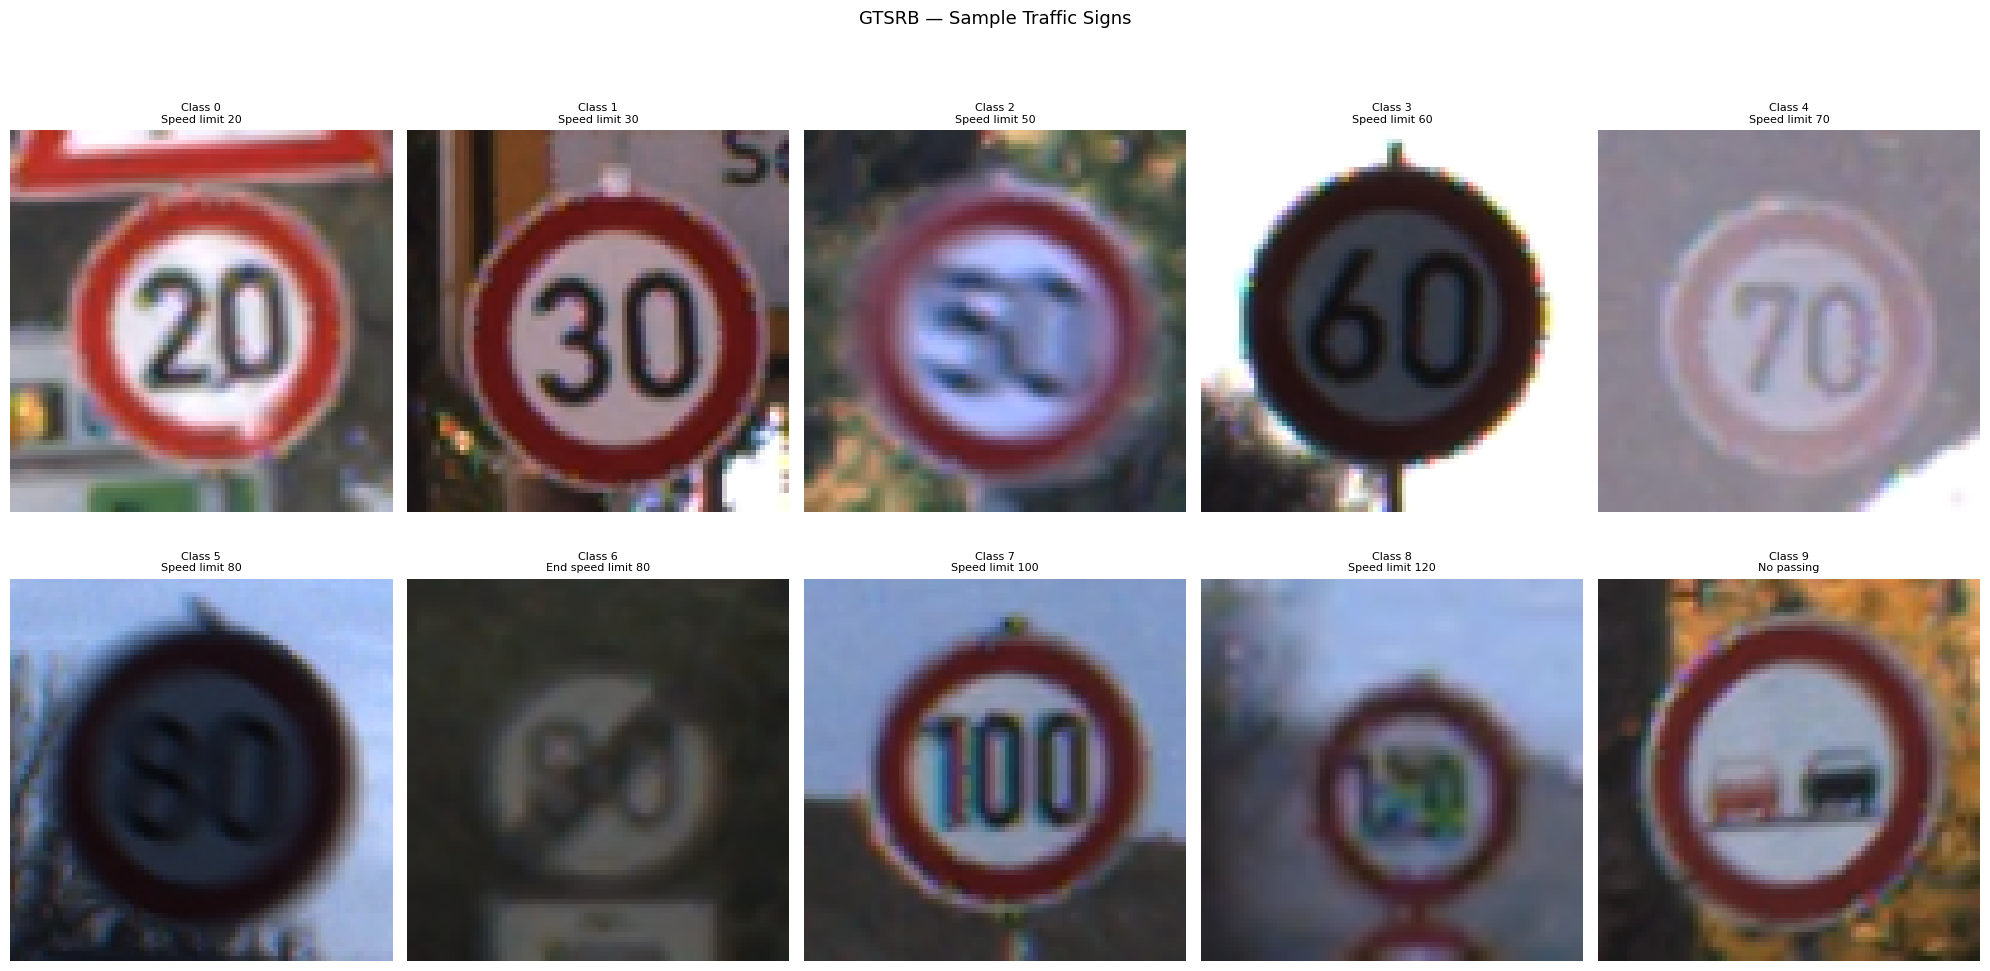

Saved: sample_images.png


In [7]:
# Class names for all 43 GTSRB sign types
CLASS_NAMES = [
    'Speed limit 20',    'Speed limit 30',    'Speed limit 50',
    'Speed limit 60',    'Speed limit 70',    'Speed limit 80',
    'End speed limit 80','Speed limit 100',   'Speed limit 120',
    'No passing',        'No passing >3.5t',  'Right-of-way',
    'Priority road',     'Yield',             'Stop',
    'No vehicles',       'No vehicles >3.5t', 'No entry',
    'General caution',   'Dangerous left',    'Dangerous right',
    'Double curve',      'Bumpy road',        'Slippery road',
    'Narrow on right',   'Road works',        'Traffic signals',
    'Pedestrians',       'Children crossing', 'Bicycles crossing',
    'Ice/snow',          'Wild animals',      'End restrictions',
    'Turn right ahead',  'Turn left ahead',   'Go straight ahead',
    'Straight or right', 'Straight or left',  'Keep right',
    'Keep left',         'Roundabout',        'End no passing',
    'End no passing >3.5t'
]

# Plot sample images from 10 different classes
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
shown_classes = set()
idx = 0
for ax in axes.flat:
    while y[idx] in shown_classes:
        idx += 1
    shown_classes.add(y[idx])
    ax.imshow(X[idx])   # already normalized but imshow handles [0,1] fine
    ax.set_title(f'Class {y[idx]}\n{CLASS_NAMES[y[idx]][:21]}', fontsize=8)
    ax.axis('off')
    idx += 1

plt.suptitle('GTSRB — Sample Traffic Signs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

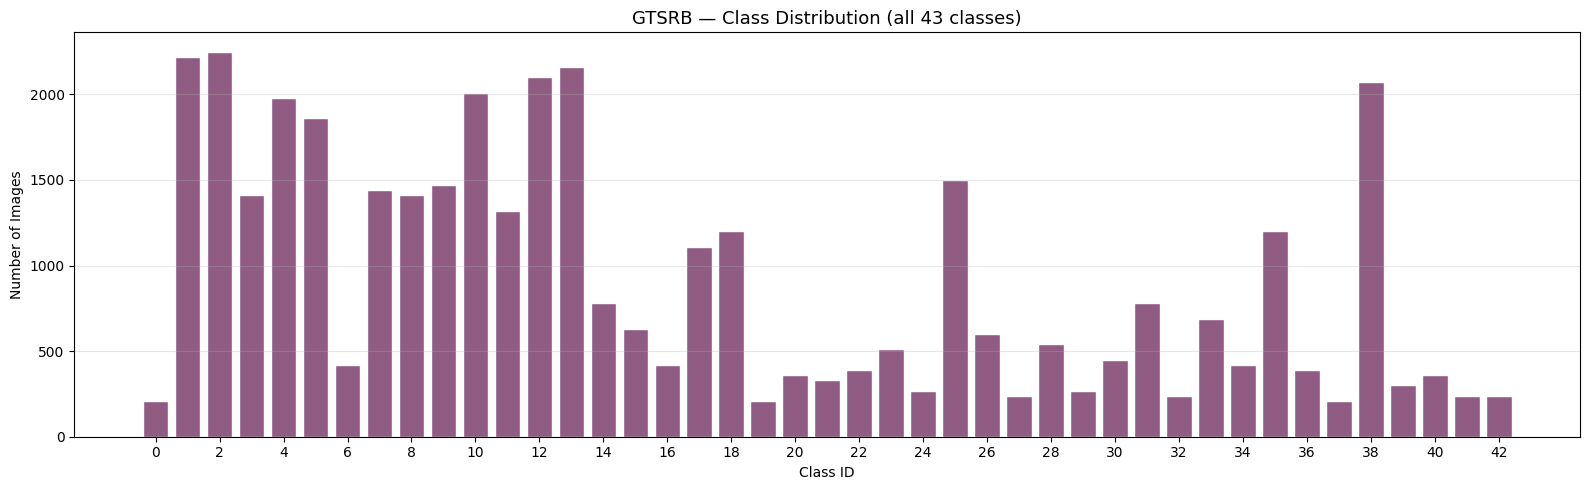

Saved: class_distribution.png

Smallest class: 210 samples | Largest class: 2250 samples
Note: class imbalance exists — stratified split handles this.


In [8]:
# Class distribution bar chart
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(16, 5))
plt.bar(unique, counts, color='#915c83', edgecolor='white')
plt.title('GTSRB — Class Distribution (all 43 classes)', fontsize=13)
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.xticks(range(0, 43, 2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')
print(f'\nSmallest class: {counts.min()} samples | Largest class: {counts.max()} samples')
print('Note: class imbalance exists — stratified split handles this.')

## Cell 6 — Data Augmentation
Applied to training data only to artificially expand the dataset and improve generalization. Not applied to test data.

In [9]:
# ── Cell 6 · Data Augmentation ──────────────────────────────────────────
# ImageDataGenerator applies random transforms to each batch on-the-fly, doesn't modifiey the original arrays

train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

print('Data augmentation Done.')

Data augmentation Done.


## Cell 7 — Build CNN Architecture
A **function** so the same architecture can be reused for both experiments by just swapping the optimizer.

**Architecture at a glance:**
```
Input (128×128×3)
  └─ Conv Block 1: Conv2D(32) → BatchNorm → MaxPool → (64×64×32)
  └─ Conv Block 2: Conv2D(64) → BatchNorm → MaxPool → (32×32×64)
  └─ Conv Block 3: Conv2D(128)→ BatchNorm → MaxPool → (16×16×128)
  └─ Flatten → Dense(256) → Dropout(0.5) → Dense(43, softmax)
```

In [10]:
def build_cnn(optimizer):

    model = Sequential([

        Conv2D(32, (3, 3),
               activation='relu',
               padding='same',
               input_shape=(IMG_SIZE, IMG_SIZE, 3)),

        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3),
               activation='relu',
               padding='same'),

        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3),
               activation='relu',
               padding='same'),

        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),

        Dense(256, activation='relu'),

        Dropout(0.5),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Cell 8 — Experiment A: Adam Optimizer (Baseline)
**What changes:** Adam optimizer with default learning rate (0.001)  
**Everything else:** same architecture, same epochs, same batch size

In [11]:
# ── Cell 8 · Experiment A — Adam Optimizer ───────────────────────────────

print('=' * 55)
print('EXPERIMENT A — Adam optimizer (lr=0.001)')
print('=' * 55)

optimizer_A = Adam(learning_rate=0.001)

model_A = build_cnn(optimizer_A)

history_A = model_A.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_A, acc_A = model_A.evaluate(X_test, y_test, verbose=0)
print(f'\nModel A (Adam) — Test Accuracy: {acc_A:.4f} | Test Loss: {loss_A:.4f}')

EXPERIMENT A — Adam optimizer (lr=0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 90s 84ms/step - accuracy: 0.2616 - loss: 2.7092 - val_accuracy: 0.4806 - val_loss: 1.4742
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 73ms/step - accuracy: 0.4326 - loss: 1.7369 - val_accuracy: 0.7057 - val_loss: 0.9305
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.6124 - loss: 1.1776 - val_accuracy: 0.8258 - val_loss: 0.5465
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - accuracy: 0.7482 - loss: 0.7701 - val_accuracy: 0.9222 - val_loss: 0.2440
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.8277 - loss: 0.5463 - val_accuracy: 0.9106 - val_loss: 0.2994
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.8782 - loss: 0.3953 - val_accuracy: 0.9844 - val_loss: 0.0516
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 75ms/step - accuracy: 0.9119 - loss: 0.2931 - val_accuracy: 0.9625 - val_loss: 0.1296
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 75ms/step - accuracy: 0.9290 - loss: 0.2531 - 

## Cell 9 — Experiment B: SGD Optimizer
**What changes:** SGD optimizer with momentum  
**Everything else:** identical to Experiment A

In [12]:
# ── Cell 9 · Experiment B — SGD Optimizer ────────────────────────────────

print('=' * 55)
print('EXPERIMENT B — SGD optimizer (lr=0.01, momentum=0.9)')
print('=' * 55)

optimizer_B = SGD(learning_rate=0.01, momentum=0.9)
model_B = build_cnn(optimizer_B)

history_B = model_B.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_B, acc_B = model_B.evaluate(X_test, y_test, verbose=0)
print(f'\nModel B (SGD)  — Test Accuracy: {acc_B:.4f} | Test Loss: {loss_B:.4f}')

EXPERIMENT B — SGD optimizer (lr=0.01, momentum=0.9)
Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 85s 82ms/step - accuracy: 0.0964 - loss: 3.5004 - val_accuracy: 0.2038 - val_loss: 3.0121
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.1629 - loss: 3.0956 - val_accuracy: 0.3361 - val_loss: 2.2372
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.3103 - loss: 2.3615 - val_accuracy: 0.5349 - val_loss: 1.3497
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 72s 74ms/step - accuracy: 0.5767 - loss: 1.3328 - val_accuracy: 0.8448 - val_loss: 0.4682
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.8217 - loss: 0.5594 - val_accuracy: 0.9332 - val_loss: 0.2171
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 75ms/step - accuracy: 0.8968 - loss: 0.3292 - val_accuracy: 0.9844 - val_loss: 0.0534
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.9295 - loss: 0.2288 - val_accuracy: 0.9861 - val_loss: 0.0466
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━

## Cell 10 — Training Curves (Requirement 8)

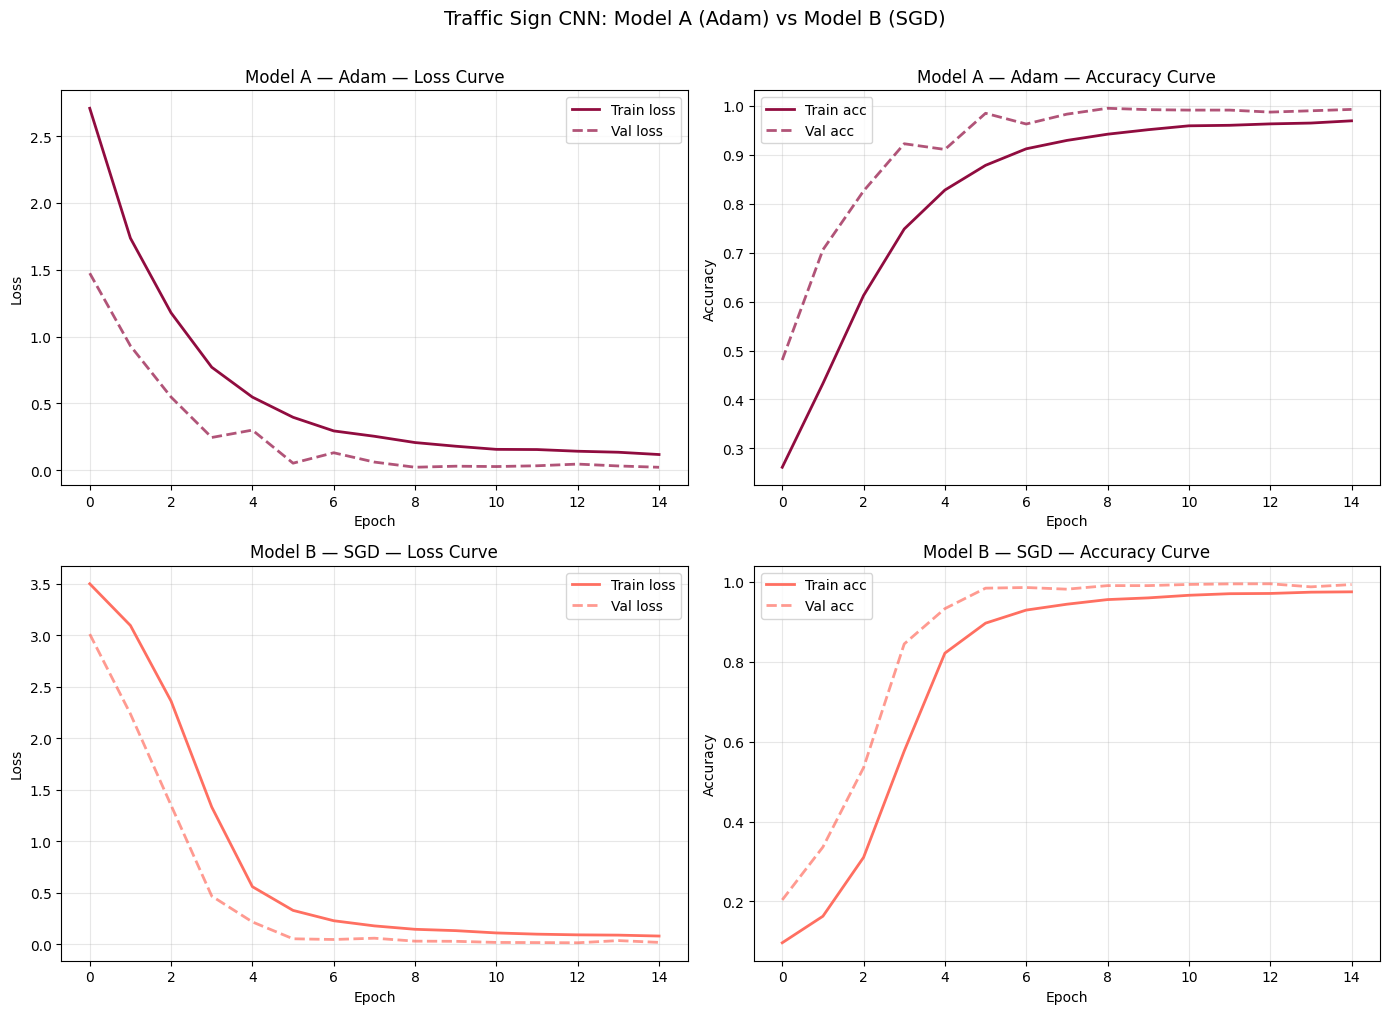

Saved: training_curves.png


In [13]:
# ── Cell 10 · Training Curves (Requirement 8) ────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model A - Loss (Top-Left)
axes[0, 0].plot(history_A.history['loss'], label='Train loss', color='#900C3F', linewidth=2)
axes[0, 0].plot(history_A.history['val_loss'], label='Val loss', color='#900C3F', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 0].set_title('Model A — Adam — Loss Curve', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Model A - Accuracy (Top-Right)
axes[0, 1].plot(history_A.history['accuracy'], label='Train acc', color='#900C3F', linewidth=2)
axes[0, 1].plot(history_A.history['val_accuracy'], label='Val acc', color='#900C3F', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 1].set_title('Model A — Adam — Accuracy Curve', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Model B - Loss (Bottom-Left)
axes[1, 0].plot(history_B.history['loss'], label='Train loss', color='#FF6F61', linewidth=2)
axes[1, 0].plot(history_B.history['val_loss'], label='Val loss', color='#FF6F61', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].set_title('Model B — SGD — Loss Curve', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Model B - Accuracy (Bottom-Right)
axes[1, 1].plot(history_B.history['accuracy'], label='Train acc', color='#FF6F61', linewidth=2)
axes[1, 1].plot(history_B.history['val_accuracy'], label='Val acc', color='#FF6F61', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Model B — SGD — Accuracy Curve', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Traffic Sign CNN: Model A (Adam) vs Model B (SGD)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## Cell 11 — Results Comparison Table (Requirement 9)

In [14]:
# ── Cell 11 · Results Comparison Table (Requirement 9) ──────────────────

print('\n' + '=' * 55)
print('Model                       Accuracy      Loss')
print('=' * 55)

print(f'Model A (Adam, lr=0.001)      {acc_A:.4f}      {loss_A:.4f}')
print(f'Model B (SGD,  lr=0.01)       {acc_B:.4f}      {loss_B:.4f}')
print('=' * 55)

if acc_A >= acc_B:
    better = 'Model A (Adam)'
else:
    better = 'Model B (SGD)'

diff = abs(acc_A - acc_B) * 100
print(f'\nBest model: {better} (difference: {diff:.2f}%)')


Model                       Accuracy      Loss
Model A (Adam, lr=0.001)      0.9923      0.0209
Model B (SGD,  lr=0.01)       0.9935      0.0185

Best model: Model B (SGD) (difference: 0.11%)


## Cell 12 — Classification Report (Best Model)

In [15]:
# ── Cell 12 · Classification Report (Best Model) ─────────────────────────

# Pick whichever model scored higher on the test set.
best_model = model_A if acc_A >= acc_B else model_B
best_name  = 'Model A (Adam)' if acc_A >= acc_B else 'Model B (SGD)'

y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f'Classification Report — {best_name}:')
print(classification_report(
    y_test_raw, y_pred,
    target_names=[f'Class {i}' for i in range(NUM_CLASSES)]
))

Classification Report — Model B (SGD):
              precision    recall  f1-score   support

     Class 0       1.00      0.95      0.98        42
     Class 1       1.00      0.97      0.98       444
     Class 2       0.95      1.00      0.98       450
     Class 3       1.00      0.98      0.99       282
     Class 4       0.99      0.99      0.99       396
     Class 5       0.99      0.97      0.98       372
     Class 6       1.00      1.00      1.00        84
     Class 7       0.97      0.99      0.98       288
     Class 8       0.99      1.00      0.99       282
     Class 9       0.99      1.00      0.99       294
    Class 10       1.00      0.99      1.00       402
    Class 11       1.00      1.00      1.00       264
    Class 12       1.00      1.00      1.00       420
    Class 13       1.00      1.00      1.00       432
    Class 14       1.00      1.00      1.00       156
    Class 15       1.00      1.00      1.00       126
    Class 16       1.00      1.00      1.0

## Cell 13 — Confusion Matrix (Best Model)

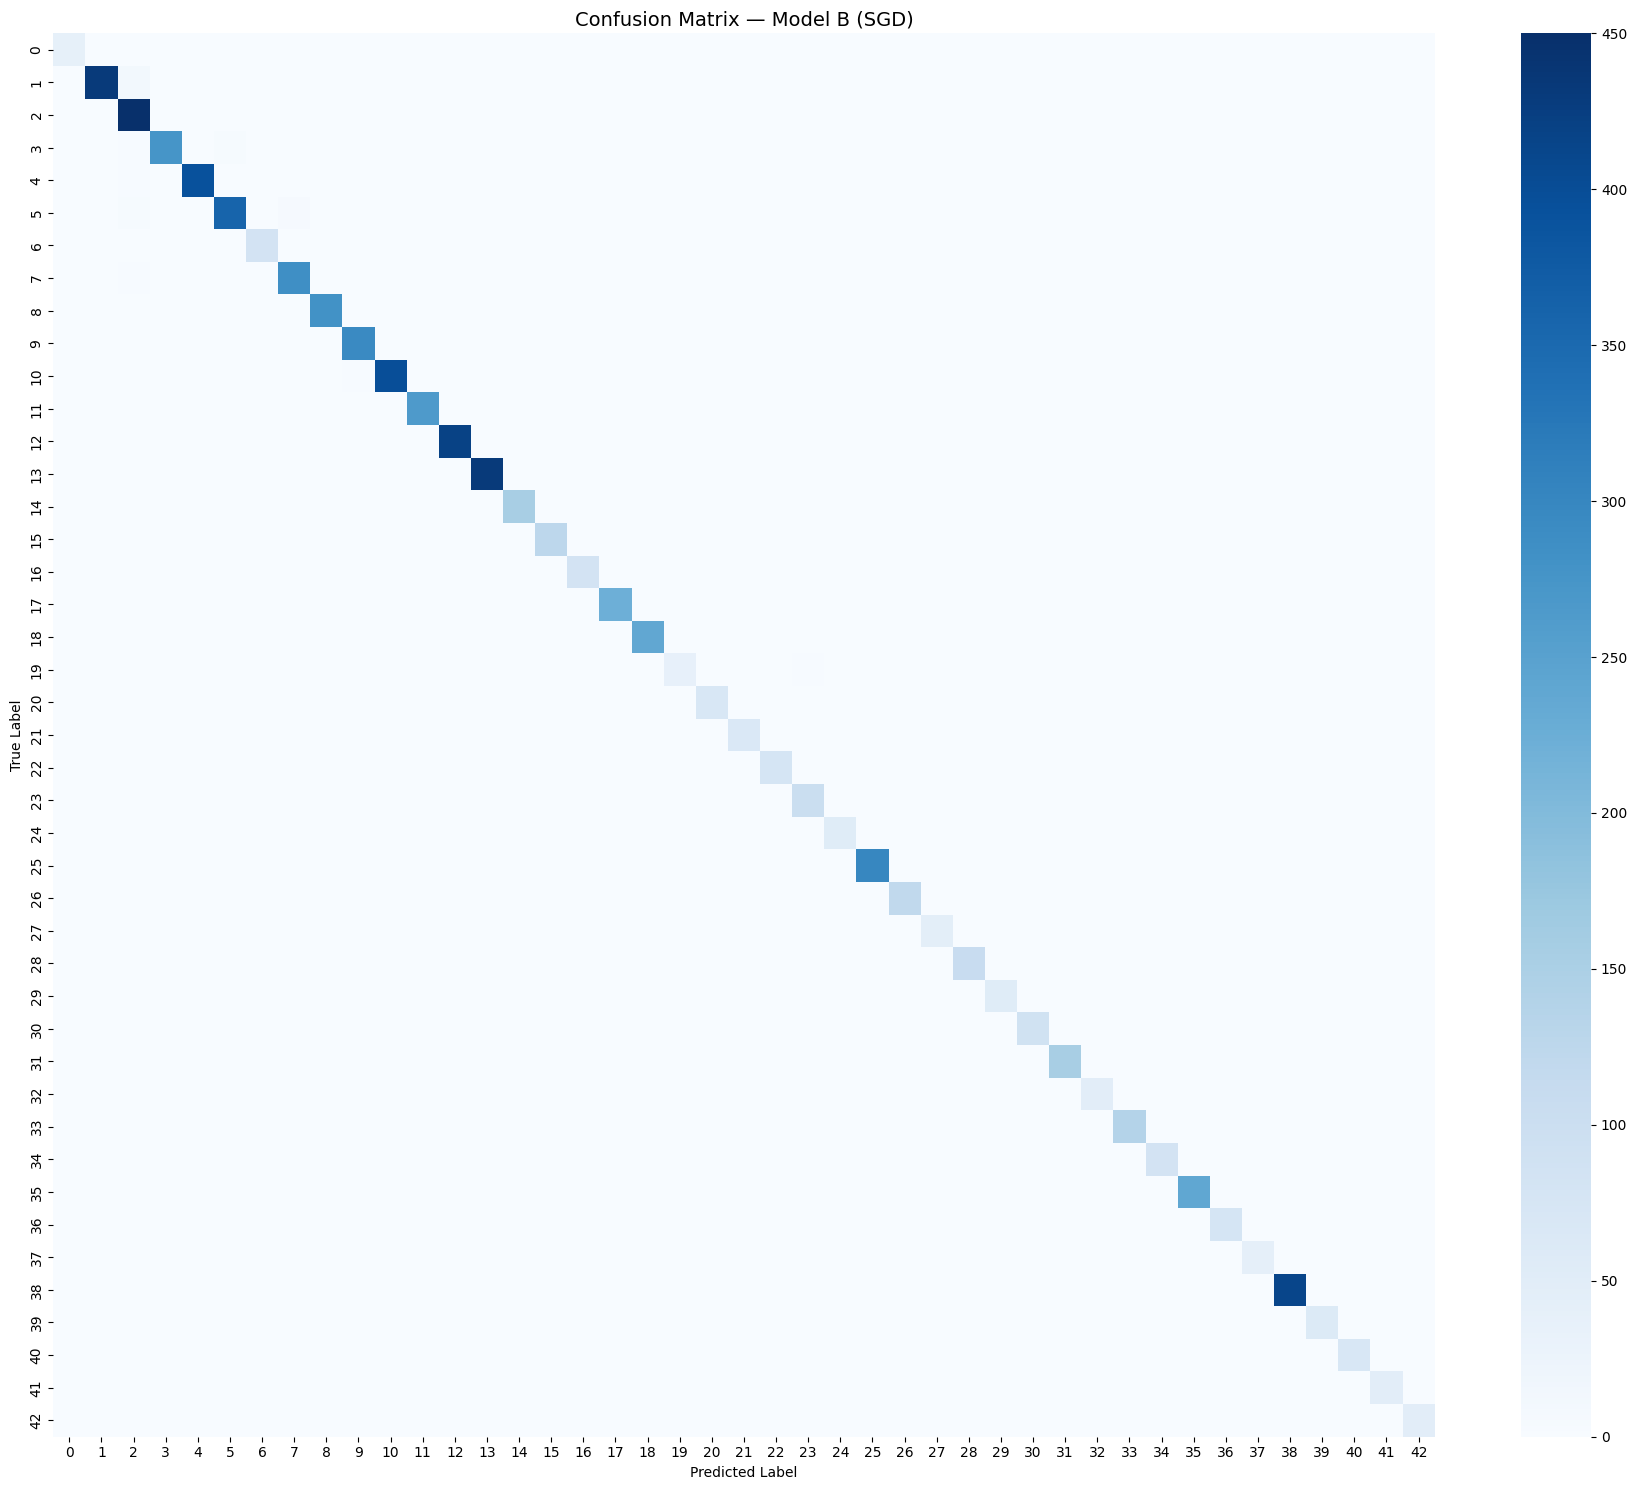

Saved: confusion_matrix.png


In [16]:
# ── Cell 13 · Confusion Matrix (Best Model) ──────────────────────────────

cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES))
plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## Cell 14 — Save Models & List All Output Files

In [17]:
# ── Cell 14 · Save Models ────────────────────────────────────────────────

model_A.save(f'{SAVE_DIR}/../model_A_adam.keras')
model_B.save(f'{SAVE_DIR}/../model_B_sgd.keras')
print('Both models saved to Google Drive.')

# List all saved output files for confirmation.
print('\nAll saved files:')
for f in os.listdir(SAVE_DIR):
    print(f'  results/{f}')

Both models saved to Google Drive.

All saved files:
  results/training_curves.png
  results/confusion_matrix.png
  results/sample_images.png
  results/class_distribution.png


## Cell 15 — Test on an External Image
Upload any traffic-sign image to Colab (`Files` panel → Upload), copy its path, paste it into `IMAGE_PATH` below, and run the cell.

The cell will display the image and show the model's top-3 predictions with confidence scores.

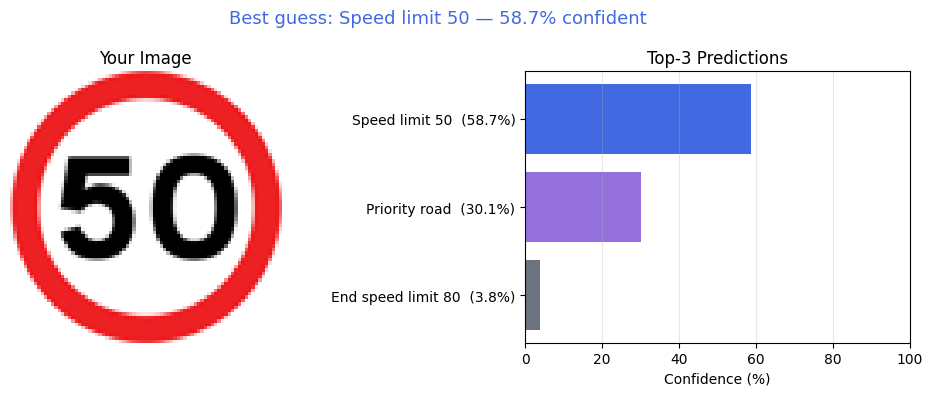


── Top-3 Predictions ──────────────────────────
  #1: Speed limit 50 - 58.67%
  #2: Priority road - 30.11%
  #3: End speed limit 80 - 3.81%


In [19]:
# ── Cell 15 · Test on an External Image ──────────────────────────────────
# PURPOSE: Let you test the model on ANY image you download and upload to Colab.

# ↓↓↓ PASTE YOUR IMAGE PATH HERE ↓↓↓
IMAGE_PATH = '/content/maximum-speed-limit-sign-50-mph.png'

img_pil = Image.open(IMAGE_PATH).convert('RGB')
img_resized = img_pil.resize((IMG_SIZE, IMG_SIZE))

img_array = np.array(img_resized, dtype=np.float32) / 255.0

img_batch = np.expand_dims(img_array, axis=0)

probs = best_model.predict(img_batch, verbose=0)[0]

# Get the indices & sort the probabilities from lowest to highest
sorted_indices = np.argsort(probs)

# Reverse the order
sorted_indices = sorted_indices[::-1]

top3_indices = sorted_indices[:3]

first_idx  = top3_indices[0]
second_idx = top3_indices[1]
third_idx  = top3_indices[2]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img_resized)
axes[0].axis('off')
axes[0].set_title('Your Image', fontsize=12)

bar_labels = [
    f"{CLASS_NAMES[third_idx]}  ({probs[third_idx]*100:.1f}%)",
    f"{CLASS_NAMES[second_idx]}  ({probs[second_idx]*100:.1f}%)",
    f"{CLASS_NAMES[first_idx]}  ({probs[first_idx]*100:.1f}%)"
]

bar_values = [
    probs[third_idx] * 100,
    probs[second_idx] * 100,
    probs[first_idx] * 100
]

# Your requested colors! Ordered bottom-to-top: Gray (3rd), Slate Blue (2nd), Royal Blue (1st)
bar_colors = ['#6B7280', '#9370db', '#4169e1']

axes[1].barh(bar_labels, bar_values, color=bar_colors)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Top-3 Predictions', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle(
    f'Best guess: {CLASS_NAMES[first_idx]} — {probs[first_idx]*100:.1f}% confident',
    fontsize=13, color='#4169e1'
)
plt.tight_layout()
plt.show()

print('\n── Top-3 Predictions ──────────────────────────')
print(f'  #1: {CLASS_NAMES[first_idx]} - {probs[first_idx]*100:.2f}%')
print(f'  #2: {CLASS_NAMES[second_idx]} - {probs[second_idx]*100:.2f}%')
print(f'  #3: {CLASS_NAMES[third_idx]} - {probs[third_idx]*100:.2f}%')